In [11]:
import geopandas as gpd
from geodatasets import get_path
import shapely
from shapely import Polygon, Point
import ee
from matplotlib import pyplot as plt
import numpy as np

import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_bounds

from shapely.geometry import Polygon, LineString
from shapely.ops import unary_union
from shapely import wkt
from pyproj import Transformer
from shapely.ops import transform
from matplotlib.patches import Patch
import pyproj
import pandas as pd
selected_bands = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
scale = 10

In [12]:
CLOUD_PROJECT = "hedgementation"

try:
    ee.Initialize(project=CLOUD_PROJECT)
except:
    ee.Authenticate()
    ee.Initialize(project=CLOUD_PROJECT)

In [38]:


def load_full_patch_dataset():
    df = pd.read_csv("../../csvs/patches_hedgerows_with_iou.csv")

    df["geometry"] = df["geometry"].apply(wkt.loads)
    df["hedgerows_2024"] = df["hedgerows_2024"].apply(
        lambda x: wkt.loads(x) if pd.notna(x) else None
    )
    df["hedgerows_2020"] = df["hedgerows_2020"].apply(
        lambda x: wkt.loads(x) if pd.notna(x) else None
    )

    gdf = gpd.GeoDataFrame(df, crs="EPSG:4326")

    floatkeys = ["area_2020", "area_2024", "net_change", "change_rate", "intersection", "union", "iou"]
    for k in floatkeys: 
        gdf[k] = gdf[k].astype(float)

    return gdf

def load_2020_disappeared_hedgerows_dataset():
    gdf = gpd.GeoDataFrame.from_file("../../gpkgs/2020_hedgerows_absent_from_2024_merged_patches.gpkg")
    gdf["hedgerows_2020"] = gdf["hedgerows"].apply(lambda x: wkt.loads(x))
    gdf["hedgerows_2024"] = pd.Series([None] * len(gdf))

    gdf["area_2020"] = gdf["hedgerows_2020"].apply(lambda x: shapely.buffer(x, distance=3.5).area)
    gdf["area_2024"] = pd.Series([0] * len(gdf))
    gdf["area_change_class"] = pd.Series(["removed"] * len(gdf))
    gdf = gdf.to_crs("ESPG:4326")
    return gdf

gdf = load_2020_disappeared_hedgerows_dataset()

In [22]:
s2 = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED').select(selected_bands)


In [23]:
import io
import requests


def transform_linestring(geometry, poly, x_length=128, y_length=128):
    minx, miny, maxx, maxy = poly.bounds

    if pd.isna(geometry):
        return None
    if isinstance(geometry, shapely.LineString):
        geoms = [geometry]
    elif isinstance(geometry, shapely.MultiLineString):
        geoms = geometry.geoms
    else:
        raise ValueError(f"Expected LineString or MultiLineString, got {type(geometry)}")


    scaled_lines = []
    for geom in geoms:
        new_coords = []
        for x,y in geom.coords:
            new_coords.append(
                [
                    x_length - (x_length * (x - minx) / (maxx-minx)),
                    y_length - (y_length * (y - miny) / (maxy - miny))
                ]
            )
        scaled_lines.append(shapely.LineString(new_coords))
    new_mls = shapely.MultiLineString(scaled_lines)
    return new_mls

def get_img_from_url(url):
    response = requests.get(url)
    tiff_bytes = io.BytesIO(response.content)

    with rasterio.open(tiff_bytes) as infile:
        img_array = np.array([infile.read(i+1) for i in range(infile.count)])
    
    blue = np.squeeze(img_array[1,:,:]).astype(np.float32)
    green = np.squeeze(img_array[0,:,:]).astype(np.float32)
    red = np.squeeze(img_array[2,:,:]).astype(np.float32)

    blue /= np.max(blue)
    green /= np.max(green)
    red /= np.max(red)

    img = np.stack([red, blue, green],axis=-1)
    return img

def download_single_img(poly, year):
    within_date = s2.filterDate(f"{year}-01-01", f"{year}-12-31")
    within_bounds = within_date.filterBounds(poly)
    within_bounds = within_bounds.filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 2))
    img = ee.Image(within_bounds.first())
    url = img.getDownloadURL({
        'scale': scale,
        'crs': ee.Projection("EPSG:3857"),
        'format': 'GEO_TIFF',
        'region': poly
    })
    
    img = get_img_from_url(url)
    return np.flip(img,axis=1)

def plot_hedgerows_on_ax(ax,
                         hedgerows,
                         color,
                         buffered=True):
    if pd.isna(hedgerows):
        return 
    if not buffered:
        for geom in hedgerows.geoms:
            x, y = geom.xy
            ax.plot(x, y, color=color, linewidth=0.7)
    else:
        try:
            for poly in hedgerows.geoms:
                x, y = poly.exterior.xy
                ax.fill(x, y, color=color)
        except:
            x, y = hedgerows.exterior.xy
            ax.fill(x, y, color=color)
            

def setup_ax(ax,img):
    ax.set_xlim(0,129)
    ax.set_ylim(0,129)
    ax.imshow(img)
    ax.set_xticks([])
    ax.set_yticks([])

def plot_img_and_hedgerows(ax1, 
                        ax2, 
                        img, 
                        hedgerows,
                        year, 
                        color="cyan", 
                        buffered=True):

    setup_ax(ax1,img)
    setup_ax(ax2,img)

    ax1.set_title(f"Satellite Image From {year}")
    ax2.set_title(f"{year} w/ Hedgerows")

    ax1.set_xlim
    plot_hedgerows_on_ax(ax2, 
                         hedgerows, 
                         color, 
                         buffered=buffered)

    

def compare_imgs_across_years(gdf, 
                              show_difference=True,
                              buffered=True,
                              query=None):
    
    if query:
        gdf = gdf.query(query)
        if len(gdf) == 0:
            print(f"Your query '{query}' resulted in an empty dataframe.")
            return
    row = gdf.sample(1).iloc[0]
    poly = row.geometry
    ee_poly = ee.Geometry.Polygon(list(poly.exterior.coords), proj=ee.Projection("EPSG:4326"))

    img_2020 = download_single_img(ee_poly, "2020")
    img_2024 = download_single_img(ee_poly,"2024")

    
    hedgerows_2020 = transform_linestring(row["hedgerows_2020"], poly)
    hedgerows_2024 = transform_linestring(row["hedgerows_2024"], poly)
    if buffered:
        hedgerows_2020 = shapely.buffer(hedgerows_2020, 0.35)
        hedgerows_2024 = shapely.buffer(hedgerows_2024, 0.35)

    fig, axs = plt.subplots(2, (3 if show_difference else 2))


    plot_img_and_hedgerows(axs[0,0], axs[0,1], img_2020, hedgerows_2020, "2020", buffered=buffered)
    plot_img_and_hedgerows(axs[1,0], axs[1,1], img_2024, hedgerows_2024, "2024", buffered=buffered)

    if show_difference:
        if not pd.isna(hedgerows_2020) and not pd.isna(hedgerows_2024):
            lost_rows = hedgerows_2020 - hedgerows_2024
            gained_rows = hedgerows_2024 - hedgerows_2020
        elif not pd.isna(hedgerows_2020):
            lost_rows = hedgerows_2020 
            gained_rows = None
        else:
            lost_rows = None 
            gained_rows = hedgerows_2024
        lost_ax = axs[0,2]
        gained_ax = axs[1,2]

        setup_ax(lost_ax, img_2020)
        lost_ax.set_title("2020 w/ Hedgerows (Losses Highlighted in Pink)")
        plot_hedgerows_on_ax(lost_ax, hedgerows_2020, "cyan", buffered=buffered)
        plot_hedgerows_on_ax(lost_ax, lost_rows, "magenta", buffered=buffered)

        setup_ax(gained_ax, img_2024)
        gained_ax.set_title("2024 w/ Hedgerows (Gains Highlighted in Pink)")
        plot_hedgerows_on_ax(gained_ax, hedgerows_2024, "cyan", buffered=buffered)
        plot_hedgerows_on_ax(gained_ax, gained_rows,"magenta", buffered=buffered)
        

    plt.tight_layout()
    fig.set_figheight(10)
    fig.set_figwidth(15)
    plt.show()



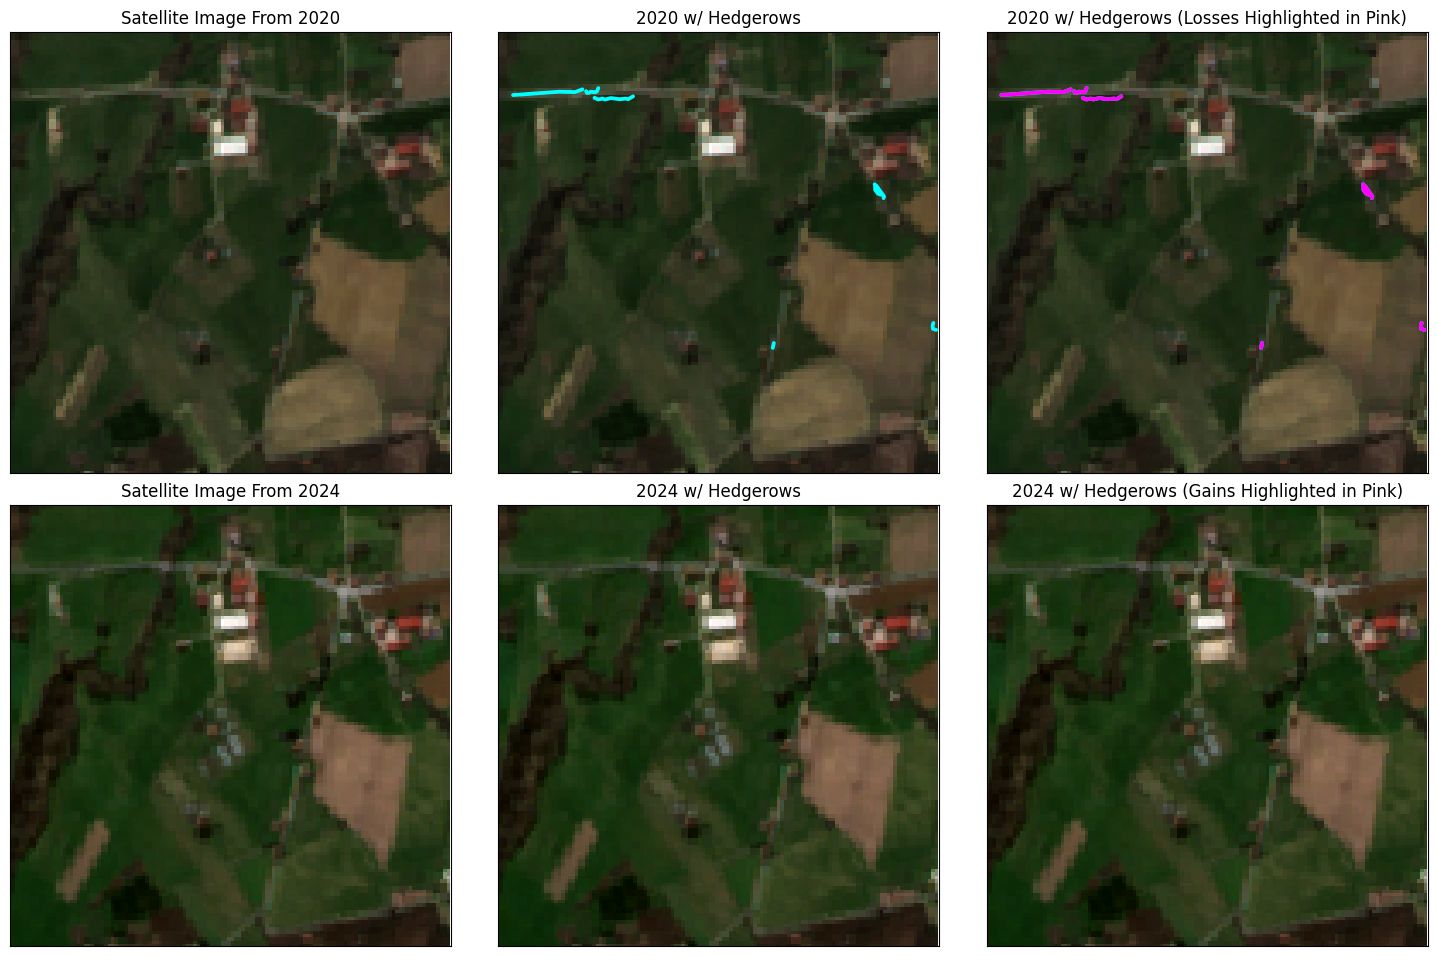

: 

In [ ]:
compare_imgs_across_years(gdf[gdf["area_2020"] > gdf["area_2020"].quantile(0.9)])


In [28]:
compare_imgs_across_years(gdf, query="change_rate >= 50 & area_2020 > 50000")

UndefinedVariableError: name 'change_rate' is not defined

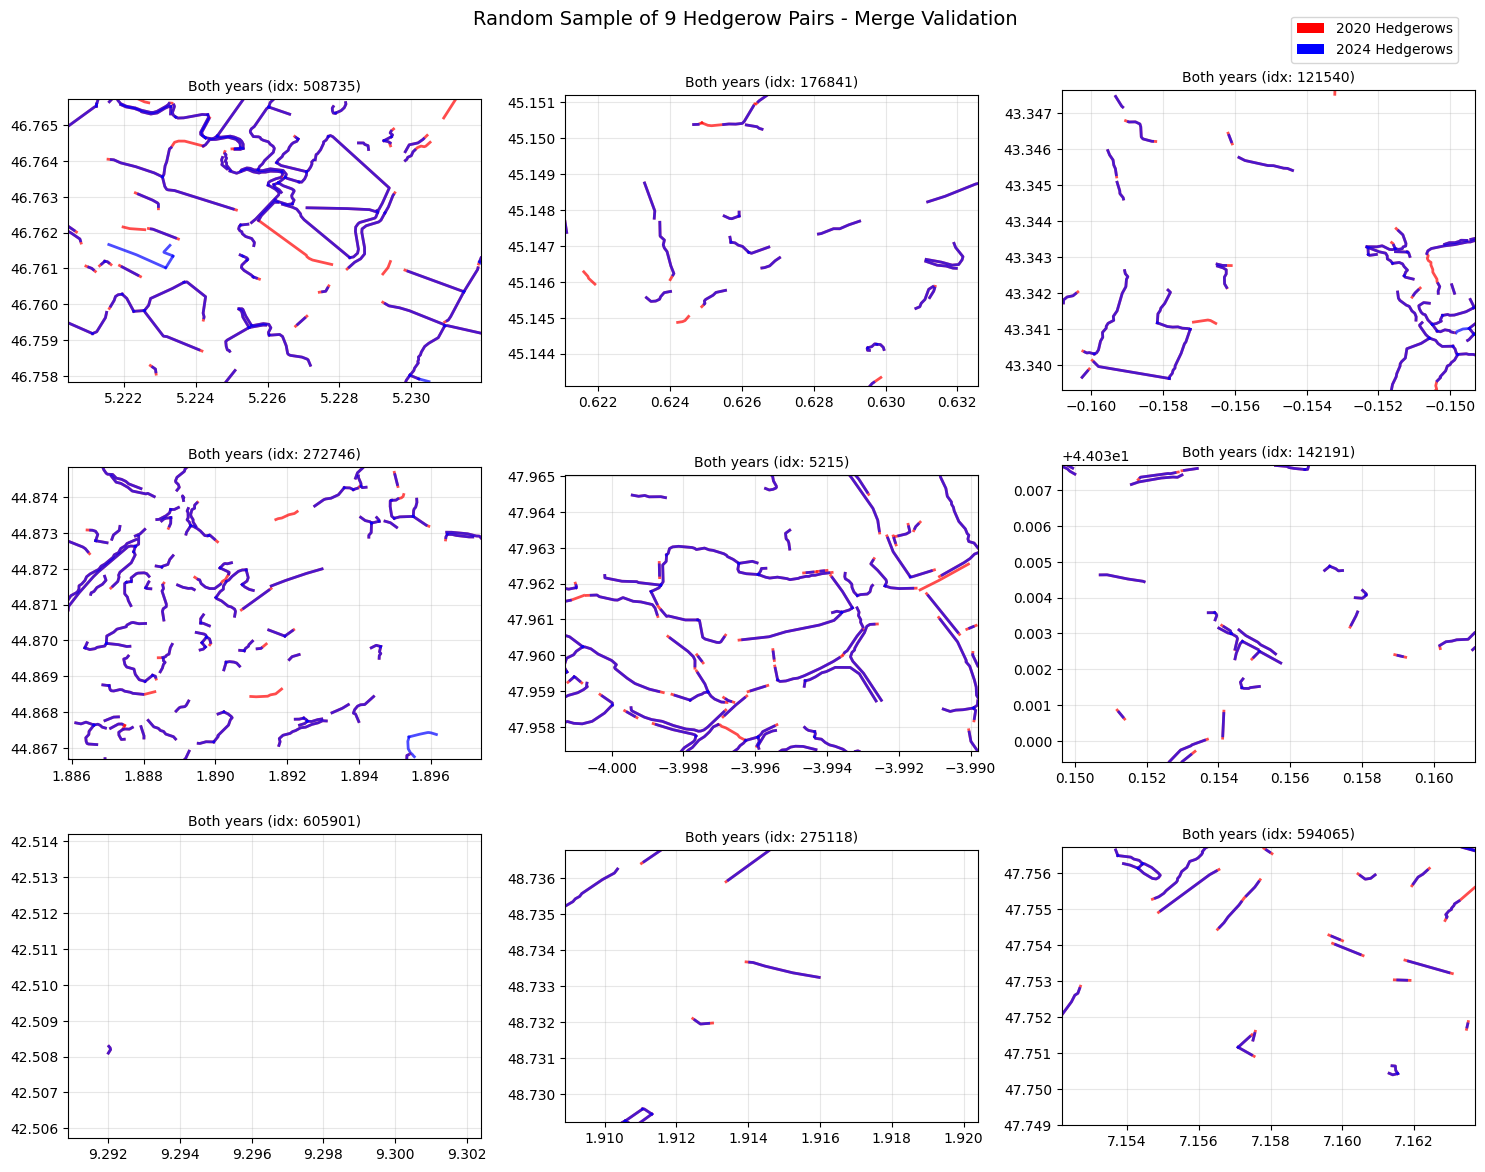

In [ ]:

def plot_hedgerows(row,ax,year=["2020","2024"],colors={
        '2020': '#ff0000',  # Orange
        '2024': '#0000ff',  # Blue  
    }):
    
    plotted_elements = set()

    minx, miny, maxx, maxy = row["geometry"].bounds
    ax.set_xlim(minx,maxx)
    ax.set_ylim(miny,maxy)


    def plot_single_hedgerow_set(year):
        if row[f'hedgerows_{year}'] is not None and not pd.isna(row[f'hedgerows_{year}']):
            if hasattr(row[f'hedgerows_{year}'], 'geoms'):  # MultiLineString
                for geom in row[f'hedgerows_{year}'].geoms:
                    x, y = geom.xy
                    ax.plot(x, y, color=colors[year], linewidth=2, alpha=0.7)
            else:  
                x, y = row[f'hedgerows_{year}'].xy
                ax.plot(x, y, color=colors[year], linewidth=2, alpha=0.7)
            plotted_elements.add(year)

    for year in year:
        plot_single_hedgerow_set(year)

    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    
    title_parts = []
    if '2020' in plotted_elements and '2024' in plotted_elements:
        title_parts.append("Both years")
    elif '2020' in plotted_elements:
        title_parts.append("2020 only")
    elif '2024' in plotted_elements:
        title_parts.append("2024 only")
    
    if hasattr(row, 'name'):
        title_parts.append(f"(idx: {row.name})")
    
    ax.set_title(" ".join(title_parts), fontsize=10)
    
    ax.set_xlabel('')
    ax.set_ylabel('')


def visualize_hedgerow_sample(gdf, filter_class=None, n_samples=9, figsize=(15, 12)):
    colors = {
        '2020': '#ff0000', 
        '2024': '#0000ff',   
    }

    if filter_class:
        gdf = gdf[gdf["area_change_class"] == filter_class]
    valid_rows = gdf[
        (gdf['hedgerows_2020'].notna()) | 
        (gdf['hedgerows_2024'].notna())
    ].copy()

    if len(valid_rows) < n_samples:
        print(f"Warning: Only {len(valid_rows)} valid rows available, showing all of them")
        n_samples = len(valid_rows)

    sample_rows = valid_rows.sample(n=n_samples)

    n_cols = int(np.ceil(np.sqrt(n_samples)))
    n_rows = int(np.ceil(n_samples / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    if n_samples == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if n_rows > 1 else axes


    for idx, (_, row) in enumerate(sample_rows.iterrows()):
        ax = axes[idx] if n_samples > 1 else axes[0]
        plot_hedgerows(row,ax)
        
    for idx in range(n_samples, len(axes)):
        axes[idx].set_visible(False)

    legend_elements = [
        Patch(facecolor=colors['2020'], label='2020 Hedgerows'),
        Patch(facecolor=colors['2024'], label='2024 Hedgerows')
    ]
    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98))

    plt.tight_layout()
    plt.suptitle(f'Random Sample of {n_samples} Hedgerow Pairs - Merge Validation{f"(Only {filter_class})" if filter_class else ""}', 
                    fontsize=14, y=0.98)
    plt.subplots_adjust(top=0.93)
    plt.show()
visualize_hedgerow_sample(gdf)

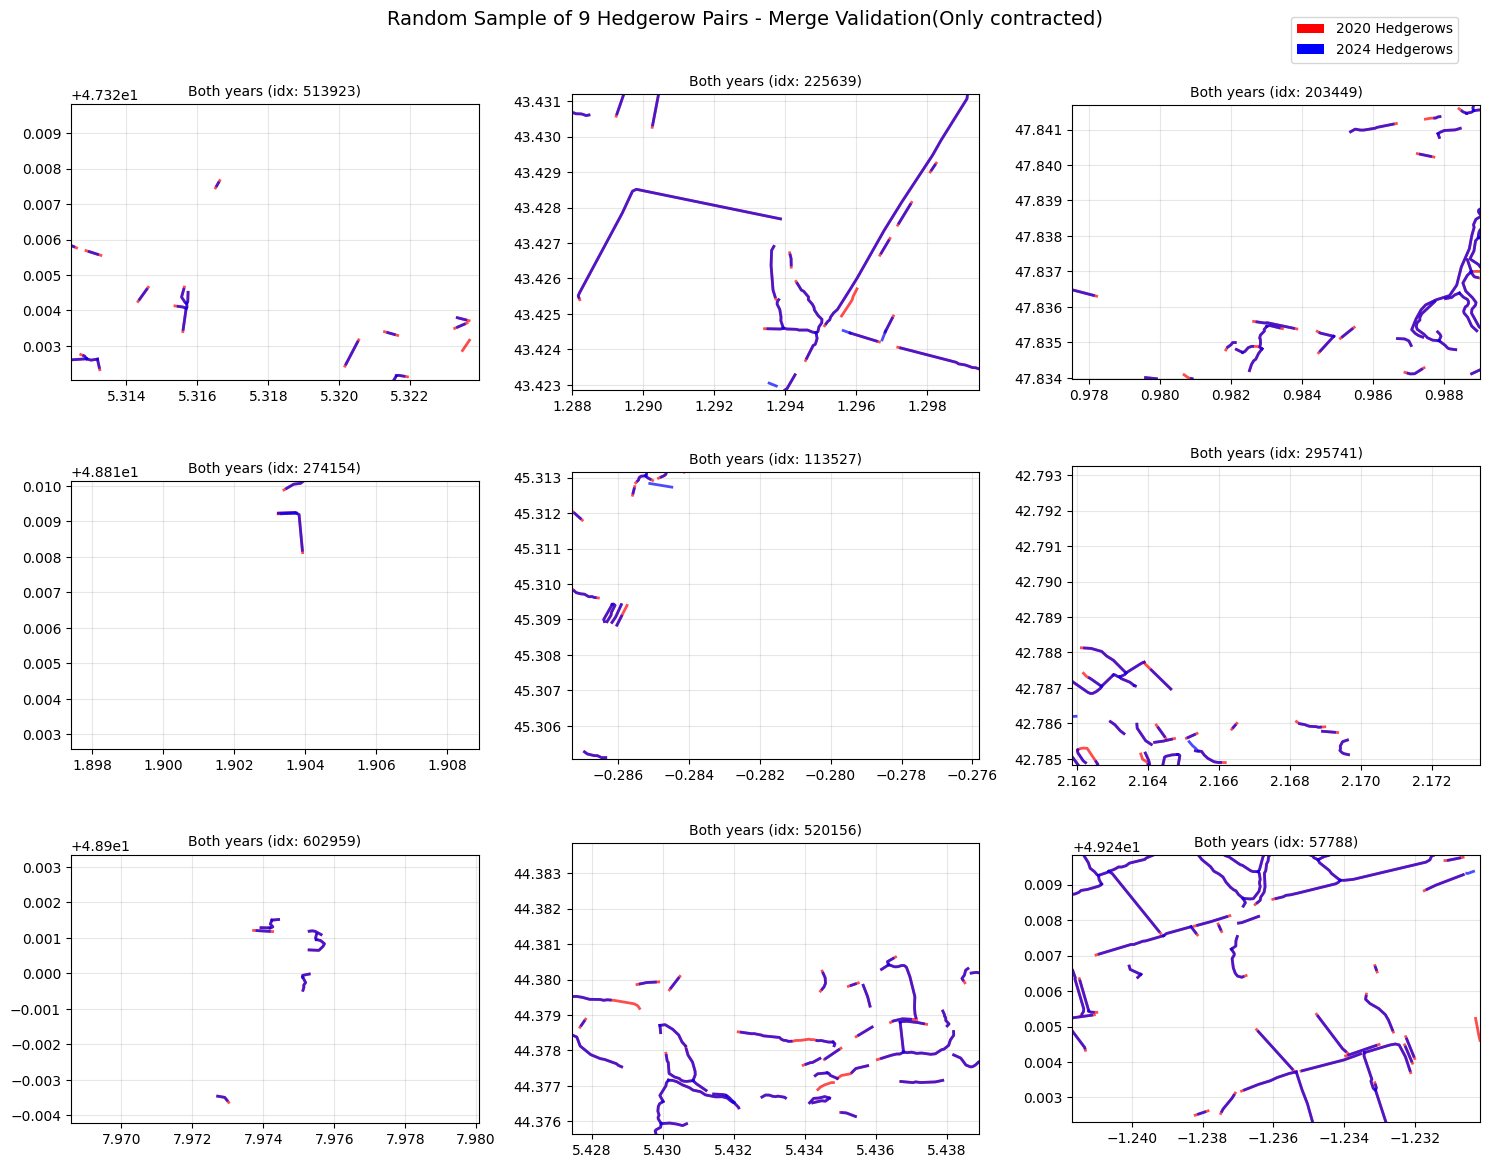

In [ ]:
visualize_hedgerow_sample(gdf, filter_class="contracted")